**Project Overview:** This regresson project utilizes car data to predict the continuous variable of miles per gallon. Notebook sections include exploratory data analysis, visualization EDA, and machine learning. Ridge and Random Forest Regression models are evaluated with the final model being chosen based on cross validation scoring. Regression metrics including R2, MSE, and MAE are calculated to determine model performance. Finally, feature evalulation is completed to determine which features possessed the highest predictive power of the MPG target variable.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
#Set Notebook & Plotting style
plt.style.use('ggplot')
%matplotlib inline
output_divider = '=' * 90
pd.set_option('display.max_columns', None)

**Part 1: Initial EDA**

In [3]:
print("Loading Data:")
print(output_divider)
df = sns.load_dataset('mpg')
print("First Five Rows Of Data:")
df.head()

Loading Data:
First Five Rows Of Data:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
print("Data Frame Size:", df.size, '|', "DataFrame Shape:", df.shape)
print(output_divider)
print("Summary Level Statistics:")
df.describe()

Data Frame Size: 3582 | DataFrame Shape: (398, 9)
Summary Level Statistics:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [5]:
print("Data Types & Initial Missing Data Inspection:")
df.info()

Data Types & Initial Missing Data Inspection:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [6]:
missing_data = df.isna().sum()
print("Missing Data By Feature:")
print(missing_data)

Missing Data By Feature:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


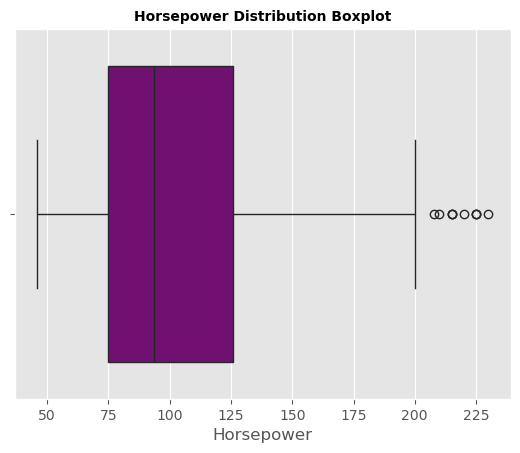

In [7]:
#Review Horsepower Distribution To Determine fillna() Method
sns.boxplot(data=df, x='horsepower', color='purple')
plt.title("Horsepower Distribution Boxplot", fontweight='bold', fontsize=10)
plt.xlabel("Horsepower")
plt.show()

In [8]:
#Fill Missing Horspower Records With The Median
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
missing_data = df.isna().sum()
print("Confirm No More Missing Data:")
print(missing_data)

Confirm No More Missing Data:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [9]:
categorical_data = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", categorical_data)
print("Unique Country Counts:", df['origin'].nunique())
print("Vehicle Name Counts:", df['name'].nunique())
print("Unique Countries Of Origin:", df['origin'].unique())

Categorical Features: ['origin', 'name']
Unique Country Counts: 3
Vehicle Name Counts: 305
Unique Countries Of Origin: ['usa' 'japan' 'europe']


In [10]:
#Standardize Capitalization For Categorical Features
df['Country'] = df['origin'].str.capitalize()
df['Car_Name'] = df['name'].str.capitalize()
df = df.drop(columns=['name', 'origin'], axis=1)
print("Data Frame Header After Category Standardization:")
df.head()

Data Frame Header After Category Standardization:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,Country,Car_Name
0,18.0,8,307.0,130.0,3504,12.0,70,Usa,Chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,Usa,Buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,Usa,Plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,Usa,Amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,Usa,Ford torino


**Part 2: Descriptive EDA**

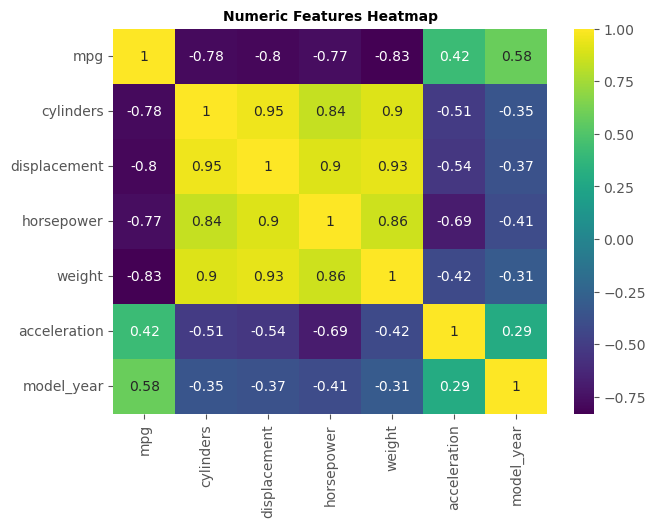

In [11]:
corr = df.select_dtypes(include=['int64', 'float64']).corr().round(2)
plt.figure(figsize=(7,5))
sns.heatmap(corr, cmap='viridis', annot=True)
plt.title("Numeric Features Heatmap", fontweight='bold', fontsize=10)
plt.show()

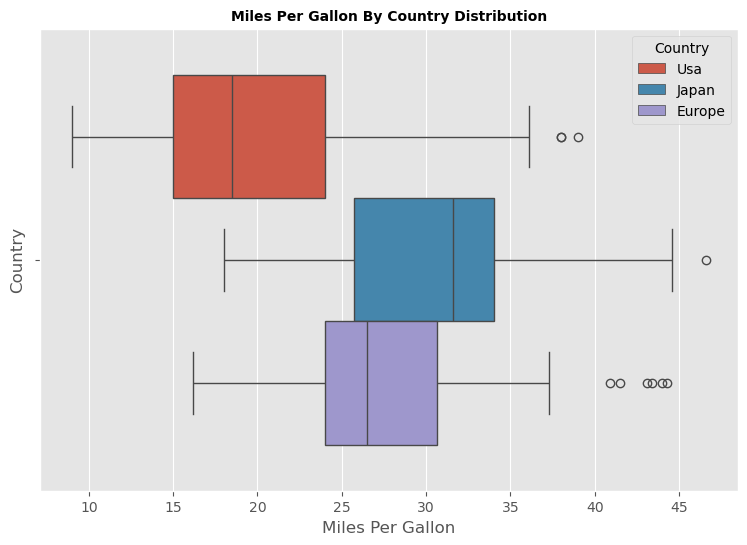

In [12]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='mpg', hue='Country')
plt.title("Miles Per Gallon By Country Distribution", fontweight='bold', fontsize=10)
plt.xlabel("Miles Per Gallon")
plt.ylabel("Country")
plt.show()

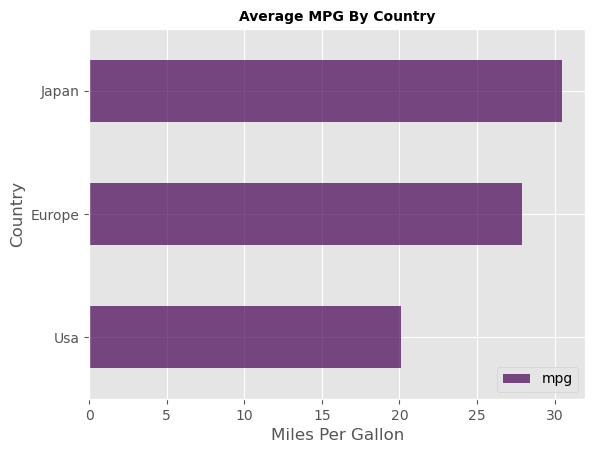

In [13]:
country_mpg = df.groupby("Country")['mpg'].mean().sort_values()
country_mpg.plot(kind='barh', cmap='viridis', legend='MPG', alpha=0.7)
plt.title("Average MPG By Country", fontweight='bold', fontsize=10)
plt.xlabel("Miles Per Gallon")
plt.ylabel("Country")
plt.legend(loc='best')
plt.show()

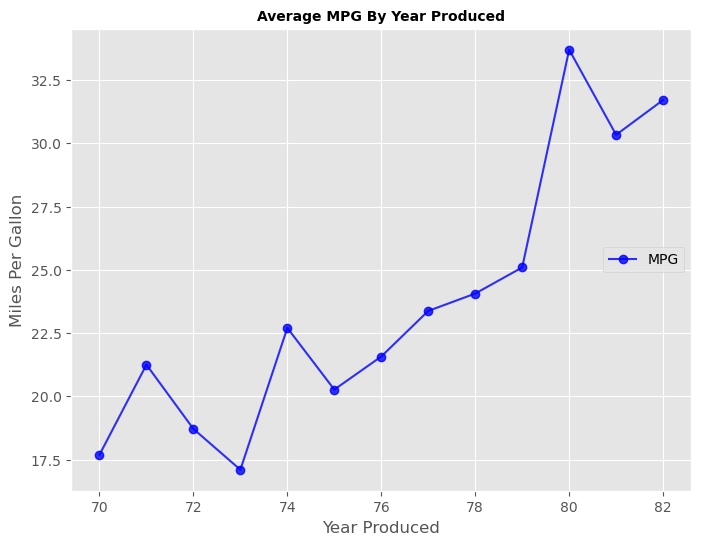

In [14]:
year_mpg = df.groupby('model_year')['mpg'].mean()
plt.figure(figsize=(8,6))
year_mpg.plot(kind='line', color='blue', marker='o', alpha=0.8, label='MPG')
plt.title("Average MPG By Year Produced", fontweight='bold', fontsize=10)
plt.xlabel("Year Produced")
plt.ylabel("Miles Per Gallon")
plt.legend(loc='center right')
plt.show()

**Part 3: Machine Learning**

**3A: Data Preprocessing**

In [15]:
X = df.drop(columns=['Car_Name', 'mpg'])
y=df['mpg']
print("Machine Learning Features:")
X.columns

Machine Learning Features:


Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model_year', 'Country'],
      dtype='object')

In [16]:
print("Target Variable Header:")
y.head()

Target Variable Header:


0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [17]:
#Separate Numeric And Categorical Features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

In [18]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

In [19]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))])

In [20]:
preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', cat_transformer, cat_features)])


In [21]:
random_state=42
cv=KFold(n_splits=5, shuffle=True, random_state=random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=random_state, test_size=0.2)

**3B: Ridge Regression**

In [22]:
Ridge_Pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Ridge', Ridge(random_state=random_state, alpha=0.01))])

In [23]:
#Cross Validation On Untuned Ridge Model 
Ridge_Untuned_CV = cross_val_score(Ridge_Pipeline, X_train, y_train, cv=cv, scoring='r2')
Ridge_Mean_Untuned = Ridge_Untuned_CV.mean()
print("Untuned Cross Validation Scores:", Ridge_Untuned_CV)
print("Untuned Mean Cross Validation Score:", Ridge_Mean_Untuned)

Untuned Cross Validation Scores: [0.81371601 0.77056589 0.8069193  0.79784102 0.82661346]
Untuned Mean Cross Validation Score: 0.8031311366547488


**3C: Ridge Paramater Tuning**

In [24]:
test_params = {'Ridge__alpha': np.logspace(-1,1,10)}
grid_search = GridSearchCV(Ridge_Pipeline, test_params, scoring='r2', cv=cv)
grid_search.fit(X_train, y_train)
print("Best Alpha Value:", grid_search.best_params_)

Best Alpha Value: {'Ridge__alpha': np.float64(2.1544346900318834)}


In [25]:
Ridge_Pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Ridge', Ridge(random_state=random_state, alpha=2.15))])

In [26]:
Ridge_Tuned_CV = cross_val_score(Ridge_Pipeline, X_train, y_train, cv=cv, scoring='r2')
Ridge_Mean_Tuned = Ridge_Tuned_CV.mean()
print("Tuned Ridge Cross Validation Scores:", Ridge_Tuned_CV)
print("Tuned Ridge Mean Cross Validation Score:", Ridge_Mean_Tuned)

Tuned Ridge Cross Validation Scores: [0.81292142 0.78209173 0.80769896 0.7959146  0.82331458]
Tuned Ridge Mean Cross Validation Score: 0.8043882566149595


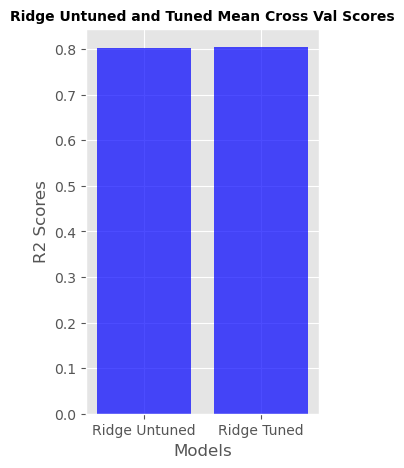

In [27]:
models = ['Ridge Untuned', 'Ridge Tuned']
scores = [Ridge_Mean_Untuned, Ridge_Mean_Tuned]
plt.figure(figsize=(3,5))
plt.bar(models, scores, color='blue', alpha=0.7)
plt.title("Ridge Untuned and Tuned Mean Cross Val Scores", fontweight='bold', fontsize=10)
plt.xlabel("Models")
plt.ylabel("R2 Scores")
plt.show()

**3D: Random Forest Regression**

In [28]:
RF_Pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Random_Forest', RandomForestRegressor(random_state=random_state, n_estimators=50,
                                   max_depth=10))])

In [29]:
Untuned_RF_CV = cross_val_score(RF_Pipeline, X_train, y_train, cv=cv, scoring='r2')
Untuned_RF_Mean = Untuned_RF_CV.mean()
print("Untuned RF Cross Validation Scores:", Untuned_RF_CV)
print("Untuned RF Mean Score:", Untuned_RF_Mean)

Untuned RF Cross Validation Scores: [0.86391815 0.86832287 0.81020624 0.8184587  0.87519268]
Untuned RF Mean Score: 0.8472197295928726


**3E: Random Forest Regression Parameter Tuning**

In [30]:
param_grid = {'Random_Forest__n_estimators' : [50, 100, 150, 200],
              'Random_Forest__max_depth': [None, 5, 10, 15]}
RF_param_search = GridSearchCV(RF_Pipeline, param_grid, cv=cv, scoring='r2')
RF_param_search.fit(X_train, y_train)
print("Best RF Parameters:", RF_param_search.best_params_)

Best RF Parameters: {'Random_Forest__max_depth': None, 'Random_Forest__n_estimators': 100}


In [31]:
RF_Pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Random_Forest', RandomForestRegressor(random_state=random_state, n_estimators=100,
                                   max_depth=None))])

In [32]:
Tuned_RF_CV = cross_val_score(RF_Pipeline, X_train, y_train, cv=cv, scoring='r2')
Tuned_RF_Mean = Tuned_RF_CV.mean()
print("Untuned RF Cross Validation Scores:", Tuned_RF_CV)
print("Untuned RF Mean Score:", Tuned_RF_Mean)

Untuned RF Cross Validation Scores: [0.86956609 0.87082817 0.81872864 0.8218734  0.88197375]
Untuned RF Mean Score: 0.8525940096326459


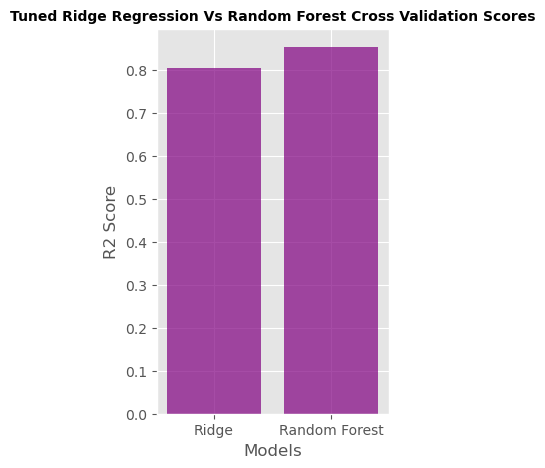

In [33]:
models = ['Ridge', 'Random Forest']
scores = [Ridge_Mean_Tuned, Tuned_RF_Mean]
plt.figure(figsize=(3,5))
plt.bar(models, scores, color='purple', alpha=0.7)
plt.title("Tuned Ridge Regression Vs Random Forest Cross Validation Scores", fontweight='bold', fontsize=10)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

In [34]:
comments = "Random Forest Regressor will be chosen as the final model based on tuned cross validation scoring."
print(comments)

Random Forest Regressor will be chosen as the final model based on tuned cross validation scoring.


**3F: Fit Final Model & Evaluate Results**

In [35]:
RF_Pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Random_Forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [36]:
y_pred = RF_Pipeline.predict(X_test)
RF_Test_Score = np.round(RF_Pipeline.score(X_test, y_test), 2)
RF_Training_Score = np.round(RF_Pipeline.score(X_train, y_train), 2)
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
print("Final RF Model Testing Score:", RF_Test_Score)
print(output_divider)
print("Final RF Model Training Score:", RF_Training_Score)
print(output_divider)
print("Final RF Model Mean Absolute Error:", MAE)
print(output_divider)
print("Final RF Model Mean Squared Error:", MSE)

Final RF Model Testing Score: 0.92
Final RF Model Training Score: 0.98
Final RF Model Mean Absolute Error: 1.5967125
Final RF Model Mean Squared Error: 4.5692149375


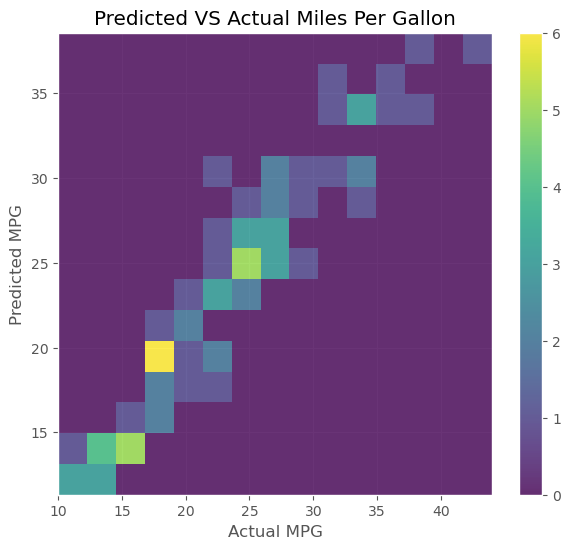

In [37]:
plt.figure(figsize=(7,6))
plt.hist2d(y_test, y_pred, cmap='viridis', bins=15, alpha=0.8)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Predicted VS Actual Miles Per Gallon")
plt.colorbar()
plt.show()

**3G: Random Forest Feature Evaluation**

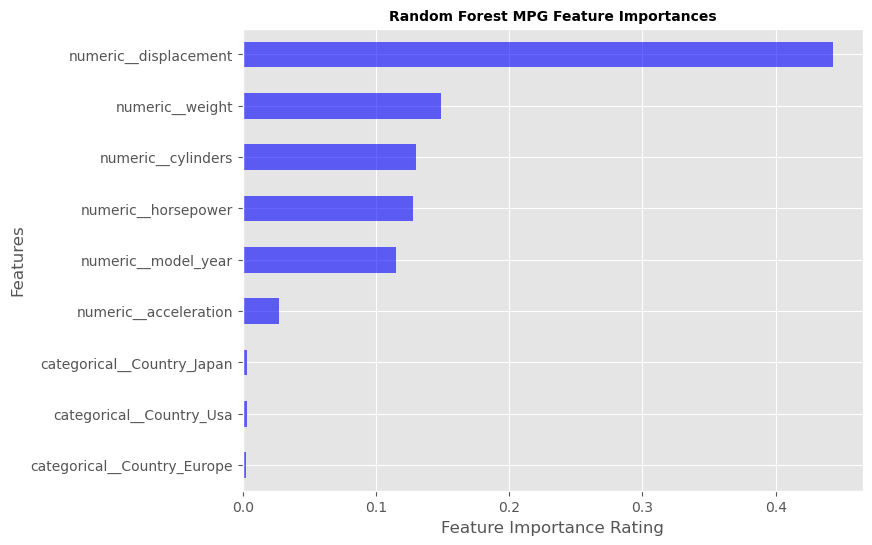

In [38]:
rf_values = RF_Pipeline.named_steps['Random_Forest'].feature_importances_
rf_features = RF_Pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_values = pd.Series(rf_values, index=rf_features).sort_values()
plt.figure(figsize=(8,6))
feature_values.plot(kind='barh', color='blue', alpha=0.6)
plt.title("Random Forest MPG Feature Importances", fontweight='bold', fontsize=10)
plt.xlabel("Feature Importance Rating")
plt.ylabel("Features")
plt.show()

**Project Findings:** Random Forest Regression was selected as the final model as it outperformed Ridge Regression in
cross validation scoring. The final model achieved an R2 score of .98 on training data and .92 on testing data indicating minimal overfitting. Numeric features proved to have the most predictive power while categorical features provided little predictive power. Vehicle displacement, weight, cylinders,
horsepower, year produced, and accelaration were most predictive of the miles per gallon continuous target variable.